# Calculate porous opacities for DSHARP constants

In [1]:
import argparse
import numpy as np
import matplotlib.pyplot as plt
import dsharp_opac as do

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


If we are running this non-interactively, parse the arguments from the commandline. To run it from the command line, you can execute:

    jupyter nbconvert --to python dsharp_porosity.ipynb

In [2]:
import __main__ as main
interactive = not hasattr(main, '__file__')
if not interactive:
    RTHF   = argparse.RawTextHelpFormatter
    PARSER = argparse.ArgumentParser(description='calculate porous DSHARP opacities', formatter_class=RTHF)
    PARSER.add_argument('-p', '--porosity', help='select porositiy', type=float, default=0.0)
    PARSER.add_argument('-s', '--smoothed', help='smooth opacities by averageing around the particle size', action='store_true')
    PARSER.add_argument('-e', '--extrapol', help='extrapolate opacities for large grains (g, S1, S2 values become invalid)', action='store_true')
    
    PARSER.add_argument('-a0', help='minimum particle size',      type=float, default=1e-5)
    PARSER.add_argument('-a1', help='maximum particle size',      type=float, default=1e3)
    PARSER.add_argument('-na', help='number of size grid points', type=int,   default=100)
    
    PARSER.add_argument('-l0', help='minimum wavelength',          type=float, default=1e-5)
    PARSER.add_argument('-l1', help='maximum wavelength',          type=float, default=1e0)
    PARSER.add_argument('-nl', help='number of wavelength points', type=int,   default=150)
    
    ARGS  = PARSER.parse_args()
    
    porosity = ARGS.porosity
    smoothed = ARGS.smoothed
    extrapol = ARGS.extrapol
    
    a0 = ARGS.a0
    a1 = ARGS.a1
    na = ARGS.na
    
    l0 = ARGS.l0
    l1 = ARGS.l1
    nl = ARGS.nl

In [11]:
ARGS.smoothed

NameError: name 'ARGS' is not defined

Select the properties in case we are running this as notebook

In [3]:
if interactive:
    print('picking values interactively')
    porosity = 0.99
    smoothed = True
    extrapol = False
    
    a0 = 1e-5
    a1 = 1e2
    na = 100
    
    l0 = 0.1
    l1 = l0
    nl = 1

picking values interactively


In [4]:
oc, rho_s = do.get_dsharp_mix(porosity=porosity,rule='Bruggeman')
import dsharp_opac as opacity
diel_const = opacity.diel_mixed([opacity.diel_vacuum(), oc.constants[1].get_normal_object()], [porosity, (1 - porosity)], rule='Maxwell-Garnett')

a   = np.logspace(np.log10(a0), np.log10(a1), na)
lam = np.logspace(np.log10(l0), np.log10(l1), nl)

smoothed=False
if smoothed:
    results = do.get_smooth_opacities(a, lam, rho_s, oc, extrapolate_large_grains=extrapol)
else:
    results = do.get_opacities(a, lam, rho_s, oc, extrapolate_large_grains=extrapol, n_angle=180)

Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & Stognienko (1996) when using these optical constants
Reading opacities from organicsk
Please cite Henning & Stognienko (1996) when using these optical constants
| material                            | volume fractions | mass fractions |
|-------------------------------------|------------------|----------------|
| Water Ice (Warren & Brandt 2008)    | 0.3642           | 0.2            |
| Astronomical Silicates (Draine 2003)| 0.167            | 0.329          |
| Troilite (Henning)                  | 0.02578          | 0.07434        |
| Organics (Henning)                  | 0.443            | 0.3966         |
using Maxwell-Garnett mixing: first component should be host material (= matrix)
    matrix = Vacuum
using Maxwell-Garnett mixing: first component should be host material (= matrix)
    matrix = Vacu

In [5]:
rho_s  = results['rho_s']
m   = 4 * np.pi / 3 * rho_s * a**3
zscat = do.calculate_mueller_matrix(lam, m, results['S1'],
                                    results['S2'], theta=results['theta'], k_sca=results['k_sca'])['zscat']

/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 3e+04%: above error tolerance
  warnings.warn(


In [6]:
a[63]

0.2848035868435799

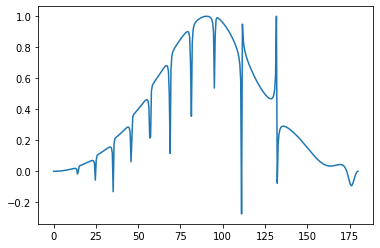

In [7]:
plt.plot(np.linspace(0,180,359), -zscat[63,0,:,1]/zscat[63,0,:,0])
#plt.xlim(80, 100)

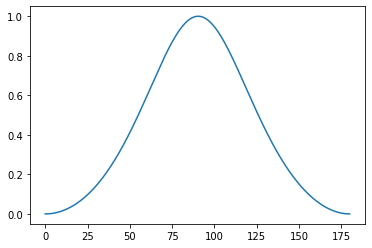

In [8]:
plt.plot(np.linspace(0,180,359), -zscat[50,0,:,1]/zscat[50,0,:,0])
#plt.xlim(80, 100)

In [9]:
fname

NameError: name 'fname' is not defined

Store results

In [ ]:
np.savez_compressed(
    fname+"",
    a     = results['a'],
    lam   = results['lam'],
    k_abs = results['k_abs'],
    k_sca = results['k_sca'],
    g     = results['g'],
    rho_s = results['rho_s'],
    S1    = results['S1'],
    S2    = results['S2'],
    theta = results['theta'])

In [ ]:
ls *.npz